# 4 А/В тест Ленты новостей

In [ ]:
# импортируем библиотеки и подключаемся к clickhouse
import pandas as pd
import numpy as np
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

connection = {
   'host': 'http://clickhouse.lab.karpov.courses:8123',
   'password': 'dpo_python_2020',
   'user': 'student',
   'database': 'simulator_20260520'
}


выгружаем из clickhouse разбитые по хешу с солью группы и смотрим количество юзеров в каждой

In [30]:
q = """
SELECT xxHash64(toString(user_id)||'my_salt')%5 as group,
  uniqExact(user_id)
FROM {db}.feed_actions
WHERE toDate(time) >= '2026-04-24' and toDate(time) <= '2026-04-30'
group by group
"""

ph.read_clickhouse(q, connection=connection)


,group,uniqExact(user_id)
0,0,8452
1,1,8326
2,2,8395
3,3,8492
4,4,8332


группы образовались примерно равные

### А/А тест

In [31]:
q = """
SELECT exp_group,
  user_id,
  sum(action = 'like') as likes,
  sum(action = 'view') as views,
  likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2026-04-24' and '2026-04-30'
  and exp_group in (2,3)
GROUP BY exp_group, user_id
"""
df = ph.read_clickhouse(q, connection=connection)
df.groupby('exp_group').count()

,user_id,likes,views,ctr
exp_group,,,,
2,8362,8362,8362,8362
3,8425,8425,8425,8425


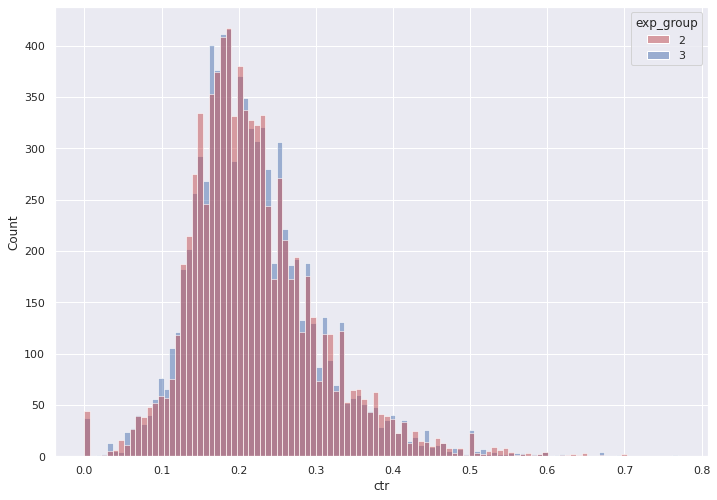

In [32]:
# Сделаем графики в seaborn покрупнее
sns.set(rc={'figure.figsize':(11.7,8.27)})
groups = sns.histplot(data = df,
             x='ctr',
             hue='exp_group',
             palette = ['r', 'b'],
             alpha=0.5,
             kde=False)


In [33]:
# сделаем Т-тест
stats.ttest_ind(df[df.exp_group == 2].ctr,
               df[df.exp_group == 3].ctr,
               equal_var=False)


Ttest_indResult(statistic=0.6617303509169987, pvalue=0.508153138292614)

In [36]:
print(stats.mannwhitneyu(df[df.exp_group == 2].ctr,
               df[df.exp_group == 3].ctr))
print('Отличие не прокрасилось')
A_gt_B = 0
for _ in range(10000):
   A_gt_B+= df[df.exp_group == 2].ctr.sample().values[0] > df[df.exp_group ==
3].ctr.sample().values[0]
   
print('В', A_gt_B/100, '% случаев A > B. Должно получиться около 50%')

MannwhitneyuResult(statistic=35290681.5, pvalue=0.8340910379715747)
Отличие не прокрасилось
В 50.04 % случаев A > B. Должно получиться около 50%


### Вывод по А/А тесту: визуально по гистаграмме, а также по результатам t-test и теста Манна-Уитни видим, что существенных различий между группами нет.

## Пришло время проанализировать результаты А/В теста, который мы провели вместе с командой дата сайентистов. Эксперимент проходил с 2026-05-01 по 2026-05-07 включительно. Для эксперимента были задействованы 2 и 1 группы. В группе 2 был использован один из новых алгоритмов рекомендации постов, группа 1 использовалась в качестве контроля. Основная гипотеза заключается в том, что новый алгоритм во 2-й группе приведет к увеличению CTR. 

In [37]:
# загрузим данные и посмотрим на группы
q = """
SELECT exp_group,
  user_id,
  sum(action = 'like') as likes,
  sum(action = 'view') as views,
  likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2026-05-01' and '2026-05-07'
  and exp_group in (1,2)
GROUP BY exp_group, user_id
"""
df = ph.read_clickhouse(q, connection=connection)
df.groupby('exp_group').count()

,user_id,likes,views,ctr
exp_group,,,,
1,10020,10020,10020,10020
2,9877,9877,9877,9877


Сравним CTR в двух группах

#### 1. Посмотрим на результаты T-теста

In [38]:
stats.ttest_ind(df[df.exp_group == 1].ctr,
               df[df.exp_group == 2].ctr,
               equal_var=False)

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

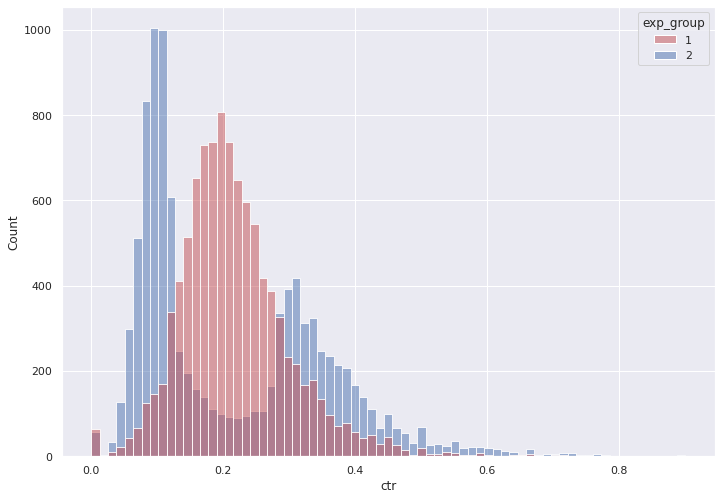

In [39]:
groups = sns.histplot(data = df,
             x='ctr',
             hue='exp_group',
             palette = ['r', 'b'],
             alpha=0.5,
             kde=False)

#### Т-тест показал, что различия не значимы. P-value примерно равен 0.685.

#### 2. Посмотрим на результаты теста Манна-Уитни

In [40]:
stats.mannwhitneyu(df[df.exp_group == 1].ctr,
                  df[df.exp_group == 2].ctr,
                  alternative = 'two-sided')

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

#### Тест Манна-Уитни показал, что различия значимы, P-value: 4.632e-45.

#### 3. Посмотрим на результаты t-теста на сглаженном ctr (α=5)

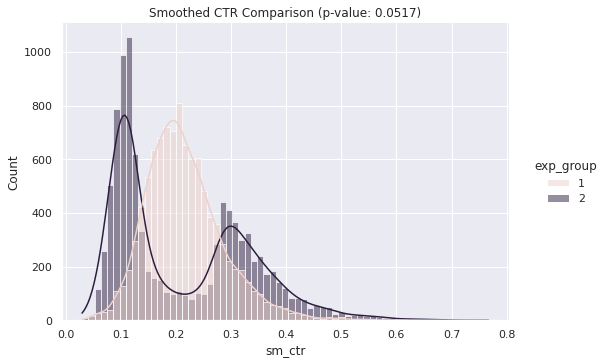

Средний сглаженный CTR 1: 0.2153
Средний сглаженный CTR 2: 0.2125
P-value: 0.05166679015318526


In [41]:
def get_smothed_ctr(user_likes, user_views, global_ctr, alpha=5):
   smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
   return smothed_ctr
q = """
SELECT exp_group,
  user_id,
  sum(action = 'like') as likes,
  sum(action = 'view') as views,
  likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2026-05-01' and '2026-05-07'
  and exp_group in (1,2)
GROUP BY exp_group, user_id
"""
df = ph.read_clickhouse(q, connection=connection)
global_ctr_1 = df[df.exp_group == 1].likes.sum()/df[df.exp_group ==
1].views.sum()
global_ctr_2 = df[df.exp_group == 2].likes.sum()/df[df.exp_group ==
2].views.sum()


df['sm_ctr'] = df.apply(
    lambda x: get_smothed_ctr(x.likes, x.views, global_ctr_1 if x.exp_group == 1 else global_ctr_2), 
    axis=1
)

# 2. Выделяем группы для сравнения
group_1 = df[df.exp_group == 1].sm_ctr
group_2 = df[df.exp_group == 2].sm_ctr

# 3. Сравниваем средние с помощью t-теста
t_stat, p_val = stats.ttest_ind(group_1, group_2, equal_var=False)

# 4. Визуализируем результат
sns.displot(df, x='sm_ctr', hue='exp_group', kde=True, height=5, aspect=1.5)
plt.title(f'Smoothed CTR Comparison (p-value: {p_val:.4f})')
plt.show()

# 5. Итоговый вывод
print(f"Средний сглаженный CTR 1: {group_1.mean():.4f}")
print(f"Средний сглаженный CTR 2: {group_2.mean():.4f}")
print(f"P-value: {p_val}")

#### t-тест на сглаженном ctr (α=5) показал, что различия значимы, P-value: 0.0517

#### 4. Посмотрим на результаты Пуассоновского бутстрепа

In [42]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):
   poisson_bootstraps1 = stats.poisson(1).rvs(
      (n_bootstrap, len(likes1))).astype(np.int64)
   poisson_bootstraps2 = stats.poisson(1).rvs(
          (n_bootstrap, len(likes2))).astype(np.int64)
   
   globalCTR1 =(poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
   
   globalCTR2 =(poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)
   return globalCTR1, globalCTR2


<Axes: ylabel='Count'>

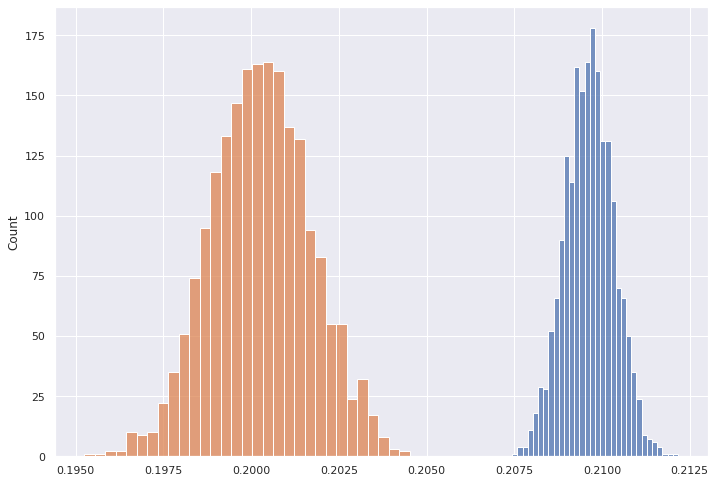

In [43]:
likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()
ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)
sns.histplot(ctr1)
sns.histplot(ctr2)


<Axes: ylabel='Count'>

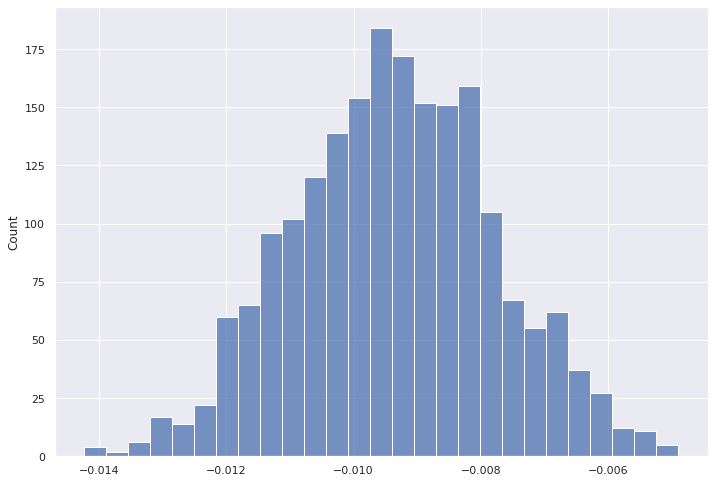

In [44]:
#Разница между глобальными CTR
sns.histplot(ctr2 - ctr1)


In [52]:
#найдем границы ДУ
lower_bound = np.percentile(ctr2 - ctr1, 2.5)
upper_bound = np.percentile(ctr2 - ctr1, 97.5)

print(f"95% Доверительный интервал: [{lower_bound:.5f}, {upper_bound:.5f}]")

95% Доверительный интервал: [-0.01235, -0.00626]


#### Пуассоновский бутстреп показал, что разница между ctr2 и ctr1 отрицательна, границы ДУ в интервале [-0.01235, -0.00626] значит CTR2 достоверно хуже CTR1.

#### 5. Посмотрим на результаты Бакетного преобразования

In [46]:
q = """
SELECT exp_group, bucket,
  sum(likes)/sum(views) as bucket_ctr,
  quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group,
      xxHash64(user_id)%50 as bucket,
      user_id,
      sum(action = 'like') as likes,
      sum(action = 'view') as views,
      likes/views as ctr
  FROM {db}.feed_actions
  WHERE toDate(time) between '2026-05-01' and '2026-05-07'
      and exp_group in (1,2)
  GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""
df = ph.read_clickhouse(q, connection=connection)
#тест Манна-Уитни видит отличие
stats.mannwhitneyu(df[df.exp_group == 1].bucket_ctr,
                  df[df.exp_group == 2].bucket_ctr,
                  alternative = 'two-sided')


MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

In [48]:
#и t-тест тоже
stats.ttest_ind(df[df.exp_group == 1].bucket_ctr,
                  df[df.exp_group == 2].bucket_ctr,
                  equal_var = False)

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)

#### T-test и тест Манна-Уитни поверх Бакетного преобразования показали, что  различия значимы, оба P-value < 0,05.

#### Повторим все результаты:
#### - т-тест показал, что различия не значимы. P-value: 0.685;
#### - тест Манна-Уитни показал, что различия значимы, P-value: 4.632e-45;
#### - т-тест на сглаженном ctr (α=5) показал, что различия значимы, P-value: 0.0517;
#### - Пуассоновский бутстреп показал, что разница между ctr2 и ctr1 отрицательна, границы ДУ в интервале [-0.01235, -0.00626] значит CTR2 достоверно хуже CTR1;
#### - т-тест и тест Манна-Уитни поверх Бакетного преобразования показали, что  различия значимы, оба P-value < 0,05.

## Общий вывод: изменения во второй группе привели к статистически значимому снижению CTR. Экспериментальный вариант (CTR2) работает хуже, чем контрольный (CTR1).

#### Почему тесты показали неоднозначный ответ? Обычный T-тест «сломался» на сырых данных, а все остальные методы указывают на наличие реального эффекта. Этот результат говорит о следующем: в данных есть сильные выбросы или экстремальная асимметрия (тяжелые хвосты). T-тест очень чувствителен к ним, из-за чего стандартная ошибка завышается, а чувствительность падает до нуля. Тест Манна-Уитни устойчив к выбросам, а Бакетное преобразование и Сглаженный CTR «лечат» проблему выбросов. Пуассоновский бутстреп ставит точку в вопросе «стало лучше или хуже». Поскольку весь доверительный интервал \([-0.012, -0.006]\) находится ниже нуля, мы уверены, что CTR2 упал относительно CTR1.

## Рекомендации: не раскатывать изменения из второй группы на всех пользователей, так как они значимо снижают CTR.